In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter as fsf
from plots.mpltoolkit import mpl_loc, fancy_legend, named_colors, load_style_sheet, negative_log
import numpy as np
import vice
import sys
import os
sys.path.insert(0, "..")
from src.utils import subsample_stars, get_velocity_evolution, get_velocity_profile
load_style_sheet("papers")
print(sys.version_info[:])

/Users/jamesjohnson/Work/Research/lib/public-dev/VICE/vice/version.py:137: VersionWarning: Using an un-released version of VICE.
  if not self.isreleased: warnings.warn("""\


(3, 12, 3, 'final', 0)


In [2]:
output = vice.output("../outputs/expifr-GSE/initial")
extra = np.genfromtxt("%s_analogdata.out" % (output.name))
output.stars["absz"] = [abs(_) for _ in extra[:,-1][:output.stars.size[0]]]

/var/folders/26/nqb98q9x5_q6brmqy4v21dqm0000gp/T/ipykernel_38381/2374489563.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


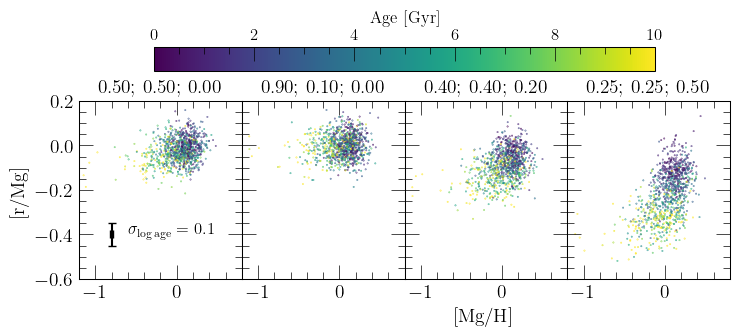

In [50]:
TL_POWERS = [0.5, 0.9, 0.4, 0.25]
PB_POWERS = [0.5, 0.1, 0.4, 0.25]
BI_POWERS = [0, 0, 0.2, 0.5]
ZONE_WIDTH = 0.1
MGH_ERR = 0.017
RMG_ERR = 0.05
LOGAGE_ERR = 0.1
COLORMAP = "viridis"

fig = plt.figure(figsize = (7.5, 3))
axes = []
for i in range(4):
    kwargs = {}
    if i:
        kwargs["sharex"] = axes[0]
        kwargs["sharey"] = axes[0]
    else: pass
    axes.append(fig.add_subplot(101 + 10 * len(TL_POWERS) + i, **kwargs))
    if i: plt.setp(axes[i].get_yticklabels(), visible = False)
    axes[i].set_title("%.2f; %.2f; %.2f" % (TL_POWERS[i], PB_POWERS[i], BI_POWERS[i]))
    # axes[i].set_title(f"%d%% %d%% %d%%" % (100 * TL_POWERS[i], 100 * PB_POWERS[i], 100 * BI_POWERS[i]))
    # axes[i].set_title(f"%d%% foobar" % (100 * TL_POWERS[i]))
axes[0].set_xlim([-1.2, 0.8])
axes[0].set_ylim([-0.6, 0.2])
axes[0].set_ylabel(r"[r/Mg]")
axes[len(axes) // 2].set_xlabel(r"[Mg/H]")

cbar_ax = fig.add_axes([0.1, 0.8, 0.8, 0.1])
norm = plt.Normalize(vmin = 0, vmax = 10)
cmap = plt.get_cmap(COLORMAP)
cbar_ax.tick_params(labelsize = 12)

def combine_channels(stars, prefactor = 1, solar = 1.0e-9, **kwargs):
    xh = len(stars["mass"]) * [0.]
    for i in range(len(xh)):
        elements = kwargs.keys()
        for elem in elements:
            xh[i] += kwargs[elem] * stars["z(%s)" % (elem)][i]
        xh[i] *= prefactor
        xh[i] = np.log10(xh[i] / solar)
    return xh

def plot_channel_combination(ax, stars, prefactor = 1, solar = 1.0e-9, powers = {}, **kwargs):
    xh = combine_channels(stars, prefactor = prefactor, solar = solar, **powers)
    age = stars["age"]
    mgh = stars["[o/h]"]
    xmg = [x - mg for x, mg in zip(xh, mgh)]
    for i in range(len(age)):
        age[i] = 10**(np.log10(age[i]) + np.random.normal(scale = LOGAGE_ERR))
        mgh[i] += np.random.normal(scale = MGH_ERR)
        xmg[i] += np.random.normal(scale = RMG_ERR)
    return ax.scatter(mgh, xmg, **kwargs)

solar_annulus = output.stars.filter(
    "zone_final", ">=", int(7 / ZONE_WIDTH)).filter(
    "zone_final", "<=", int(9 / ZONE_WIDTH) - 1).filter(
    "absz", "<=", 0.5)
solar_annulus = subsample_stars(solar_annulus, n = 1000)
for i in range(len(BI_POWERS)):
    kwargs = {
        "c": solar_annulus["age"],
        "cmap": COLORMAP,
        "vmin": 0,
        "vmax": 10,
        "rasterized": True,
        "s": 0.1
    }
    sm = plot_channel_combination(axes[i], solar_annulus, powers = {
        "tl": TL_POWERS[i],
        "pb": PB_POWERS[i],
        "bi": BI_POWERS[i]
    }, **kwargs)

cbar = plt.colorbar(sm, cax = cbar_ax, orientation = "horizontal", location = "top")
cbar.set_label(r"Age [Gyr]", fontsize = 12)

axes[0].errorbar([-0.8], [-0.4], xerr = MGH_ERR, yerr = RMG_ERR, color = named_colors()["black"])
axes[0].text(-0.6, -0.4, r"$\sigma_{\log \text{age}} = %g$" % (LOGAGE_ERR), fontsize = 12)

plt.tight_layout()
plt.subplots_adjust(wspace = 0, top = 0.8)
cbar_ax.set_position([
    axes[0].get_position().x0 + 0.1,
    axes[0].get_position().y1 + 0.1,
    axes[-1].get_position().x1 - axes[0].get_position().x0 - 0.2,
    0.08
])
plt.show()

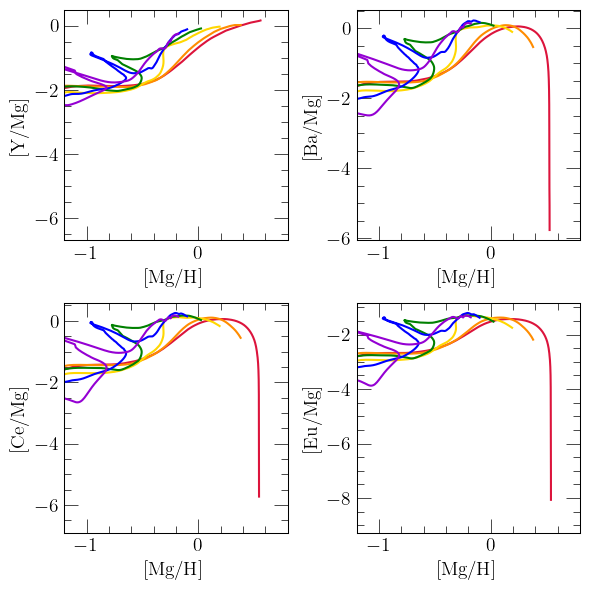

In [63]:
ELEMENTS = ["y", "ba", "ce", "eu"]
RADII = [3, 5, 7, 9, 11, 13]
COLORS = ["crimson", "darkorange", "gold", "green", "blue", "darkviolet"]

fig = plt.figure(figsize = (6, 6))
axes = []
for i in range(4):
    axes.append(fig.add_subplot(221 + i))
    axes[i].set_xlabel(r"[Mg/H]")
    axes[i].set_ylabel(r"[%s/Mg]" % (ELEMENTS[i].capitalize()))
    axes[i].set_xlim([-1.2, 0.8])

def plot_sproc_only(ax, output, element, zone_width = 0.1, **kwargs):
    for i in range(len(RADII)):
        zone = output.zones["zone%d" % (int(RADII[i] / zone_width))]
        ax.plot(zone.history["[o/h]"], zone.history["[%s/o]" % (element)], c = named_colors()[COLORS[i]], **kwargs)

for i in range(len(axes)):
    plot_sproc_only(axes[i], output, ELEMENTS[i])

plt.tight_layout()
plt.show()